In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, precision_recall_curve, accuracy_score,
                              average_precision_score)

np.random.seed(42)
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "diagnosis"}, inplace=True)

print(f"Shape: {df.shape}")
print(f"Classes: {dict(zip(data.target_names, np.unique(df['diagnosis'])))}")
df.head()

Shape: (569, 31)
Classes: {np.str_('malignant'): np.int64(0), np.str_('benign'): np.int64(1)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


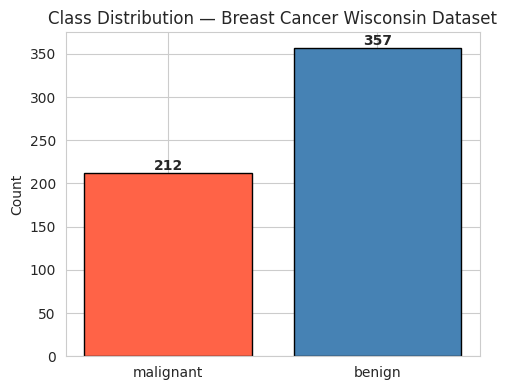

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["diagnosis"].value_counts().sort_index()
ax.bar(data.target_names, counts.values, color=["tomato", "steelblue"], edgecolor="black")
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha="center", fontweight="bold")
ax.set_title("Class Distribution — Breast Cancer Wisconsin Dataset")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [4]:
## 2. Exploratory Data Analysis


In [5]:
df.describe().T[["mean", "std", "min", "max"]].round(2)


,mean,std,min,max
mean radius,14.13,3.52,6.98,28.11
mean texture,19.29,4.30,9.71,39.28
mean perimeter,91.97,24.30,43.79,188.50
mean area,654.89,351.91,143.50,2501.00
mean smoothness,0.10,0.01,0.05,0.16
mean compactness,0.10,0.05,0.02,0.35
mean concavity,0.09,0.08,0.00,0.43
mean concave points,0.05,0.04,0.00,0.20
mean symmetry,0.18,0.03,0.11,0.30
mean fractal dimension,0.06,0.01,0.05,0.10


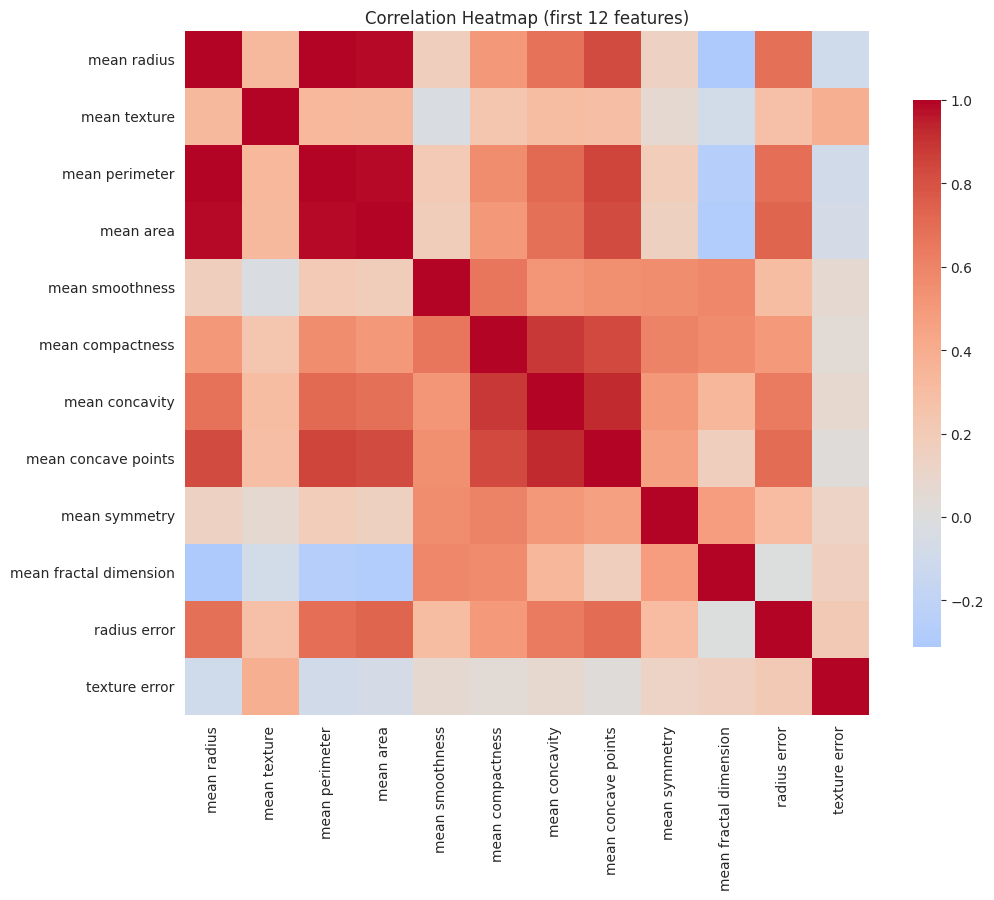

In [6]:
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["diagnosis"]).iloc[:, :12].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (first 12 features)")
plt.tight_layout()
plt.show()

In [7]:
## 3. Preprocessing


In [8]:
FEATURES = list(data.feature_names)
X = df[FEATURES].values.astype(float)
y = df["diagnosis"].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")


Train: (455, 30), Test: (114, 30)


In [9]:
## 4. Logistic Regression Engine (implemented from scratch)


In [10]:
def sigmoid(z):
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))


def bce_loss(theta, X_b, y, lam=0.0):
    m = y.size
    eps = 1e-9
    y_hat = sigmoid(X_b @ theta)
    loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    if lam > 0:
        loss += (lam / (2 * m)) * np.sum(theta[1:] ** 2)
    return loss


def gradient(theta, X_b, y, lam=0.0):
    m = y.size
    y_hat = sigmoid(X_b @ theta)
    grad = (X_b.T @ (y_hat - y)) / m
    if lam > 0:
        reg = (lam / m) * theta.copy()
        reg[0] = 0.0
        grad += reg
    return grad

In [11]:
def train_logistic_regression(X, y, optimizer="gd", lr=0.1, num_iter=1500, lam=0.01,
                               beta1=0.9, beta2=0.999, eps=1e-8, tol=1e-9):
    """From-scratch logistic regression supporting three optimizers:
       - 'gd'       : vanilla batch gradient descent
       - 'momentum' : gradient descent with classical momentum
       - 'adam'     : Adam (adaptive moment estimation)
    """
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.zeros(X_b.shape[1])
    losses = []

    v = np.zeros_like(theta)        # momentum / 1st moment
    s = np.zeros_like(theta)        # 2nd moment (Adam only)

    for t in range(1, num_iter + 1):
        loss = bce_loss(theta, X_b, y, lam)
        losses.append(loss)
        grad = gradient(theta, X_b, y, lam)

        if optimizer == "gd":
            theta -= lr * grad

        elif optimizer == "momentum":
            v = beta1 * v + (1 - beta1) * grad
            theta -= lr * v

        elif optimizer == "adam":
            v = beta1 * v + (1 - beta1) * grad
            s = beta2 * s + (1 - beta2) * (grad ** 2)
            v_hat = v / (1 - beta1 ** t)
            s_hat = s / (1 - beta2 ** t)
            theta -= lr * v_hat / (np.sqrt(s_hat) + eps)
        else:
            raise ValueError(f"Unknown optimizer: {optimizer}")

        if np.linalg.norm(grad) < tol:
            break

    return theta, losses


def predict_prob(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)


def predict(X, theta, threshold=0.5):
    return (predict_prob(X, theta) >= threshold).astype(int)


In [12]:
## 5. Optimizer Convergence Study


In [13]:
results = {}
for opt in ["gd", "momentum", "adam"]:
    lr = 0.5 if opt == "adam" else 0.3
    theta, losses = train_logistic_regression(X_train_s, y_train, optimizer=opt,
                                               lr=lr, num_iter=800, lam=0.05)
    results[opt] = {"theta": theta, "losses": losses}
    print(f"{opt:>9s}: final loss = {losses[-1]:.5f}  (in {len(losses)} iterations)")

       gd: final loss = 0.05068  (in 800 iterations)
 momentum: final loss = 0.05063  (in 800 iterations)
     adam: final loss = 0.03871  (in 800 iterations)


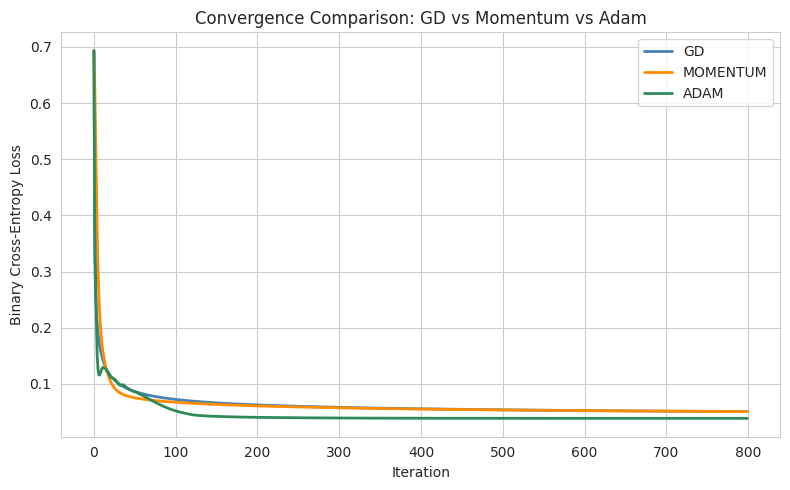

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"gd": "steelblue", "momentum": "darkorange", "adam": "seagreen"}
for opt, res in results.items():
    ax.plot(res["losses"], label=opt.upper(), color=colors[opt], linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Convergence Comparison: GD vs Momentum vs Adam")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Adam converges fastest here, so we adopt it as the optimizer for the rest of the notebook.
theta, losses = train_logistic_regression(X_train_s, y_train, optimizer="adam",
                                           lr=0.5, num_iter=1000, lam=0.05)
print(f"Final training loss: {losses[-1]:.5f}")

Final training loss: 0.03871


In [16]:
## 6. Regularization Path Analysis


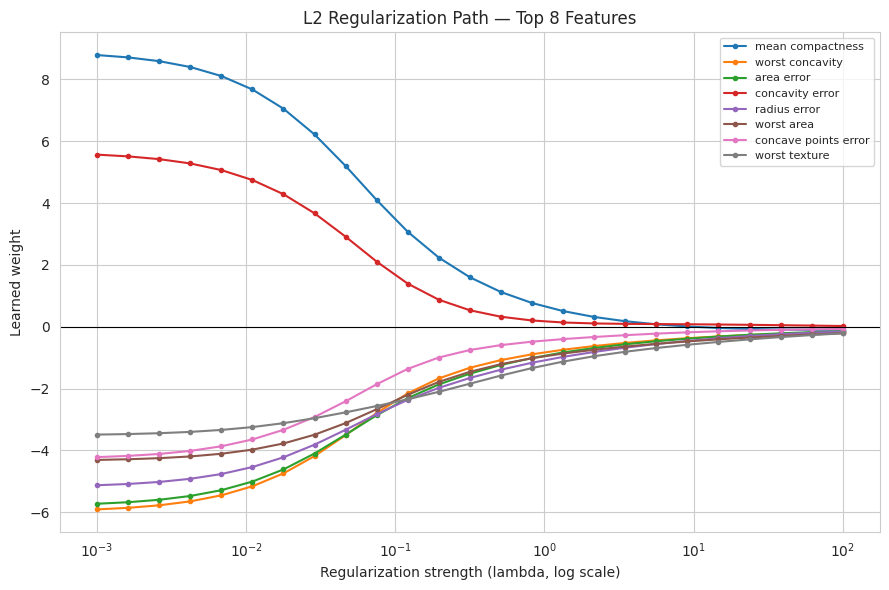

In [17]:
lambdas = np.logspace(-3, 2, 25)
weight_paths = []

for lam in lambdas:
    th, _ = train_logistic_regression(X_train_s, y_train, optimizer="adam",
                                       lr=0.5, num_iter=500, lam=lam)
    weight_paths.append(th[1:])  # drop bias

weight_paths = np.array(weight_paths)

# Show only the 8 features with the largest |weight| at the smallest lambda, for readability
top_idx = np.argsort(-np.abs(weight_paths[0]))[:8]

fig, ax = plt.subplots(figsize=(9, 6))
for idx in top_idx:
    ax.plot(lambdas, weight_paths[:, idx], marker="o", markersize=3, label=FEATURES[idx])
ax.set_xscale("log")
ax.set_xlabel("Regularization strength (lambda, log scale)")
ax.set_ylabel("Learned weight")
ax.set_title("L2 Regularization Path — Top 8 Features")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
## 7. Threshold Optimization & Evaluation


In [19]:
proba_test = predict_prob(X_test_s, theta)
fpr, tpr, roc_thresh = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

f1s = []
for thr in roc_thresh:
    pred = (proba_test >= thr).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1s.append(2 * p * r / (p + r) if (p + r) > 0 else 0)

best_thr = float(roc_thresh[int(np.argmax(f1s))])
print(f"Optimal threshold (max F1): {best_thr:.3f}  (default was 0.5)")

Optimal threshold (max F1): 0.406  (default was 0.5)


In [20]:
y_pred_custom = predict(X_test_s, theta, threshold=best_thr)

acc = accuracy_score(y_test, y_pred_custom)
print(f"Test accuracy @ optimal threshold: {acc:.4f}")
print(f"Test AUC-ROC: {auc:.4f}\n")
print(classification_report(y_test, y_pred_custom, target_names=list(data.target_names)))

Test accuracy @ optimal threshold: 0.9825
Test AUC-ROC: 0.9917

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



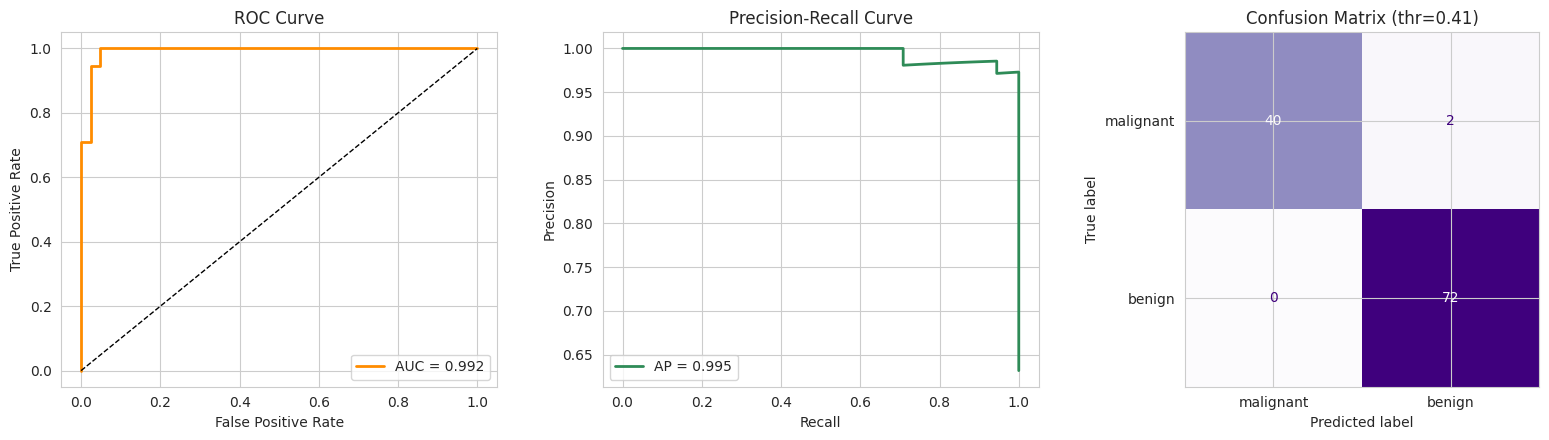

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ROC curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend(loc="lower right")

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)
axes[1].plot(rec, prec, color="seagreen", lw=2, label=f"AP = {ap:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend(loc="lower left")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=axes[2], colorbar=False, cmap="Purples")
axes[2].set_title(f"Confusion Matrix (thr={best_thr:.2f})")

plt.tight_layout()
plt.show()

In [22]:
## 8. Feature Importance


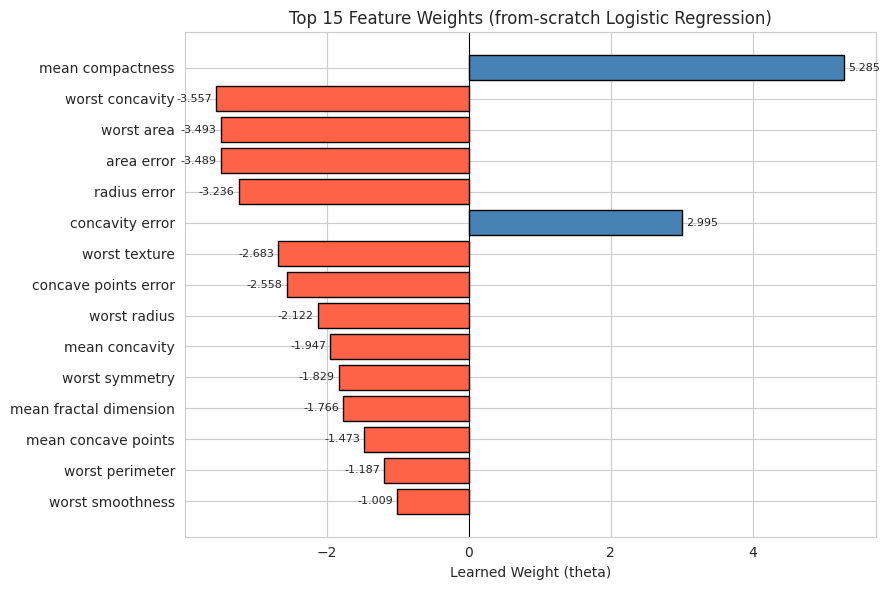

In [23]:
weights = theta[1:]
order = np.argsort(np.abs(weights))[::-1][:15]
top_features = [FEATURES[i] for i in order]
top_weights = weights[order]

colors = ["tomato" if w < 0 else "steelblue" for w in top_weights]
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_features[::-1], top_weights[::-1], color=colors[::-1], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Learned Weight (theta)")
ax.set_title("Top 15 Feature Weights (from-scratch Logistic Regression)")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
## 9. Benchmark Against scikit-learn's `LogisticRegression`


In [25]:
sk_model = SKLogisticRegression(penalty="l2", C=1/0.05, max_iter=2000, random_state=42)
sk_model.fit(X_train_s, y_train)
proba_sklearn = sk_model.predict_proba(X_test_s)[:, 1]
y_pred_sklearn = (proba_sklearn >= best_thr).astype(int)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "AUC-ROC", "Average Precision"],
    "From-Scratch": [
        accuracy_score(y_test, y_pred_custom),
        roc_auc_score(y_test, proba_test),
        average_precision_score(y_test, proba_test),
    ],
    "scikit-learn": [
        accuracy_score(y_test, y_pred_sklearn),
        roc_auc_score(y_test, proba_sklearn),
        average_precision_score(y_test, proba_sklearn),
    ],
})
comparison["Difference"] = comparison["From-Scratch"] - comparison["scikit-learn"]
comparison.round(4)


,Metric,From-Scratch,scikit-learn,Difference
0,Accuracy,0.9825,0.9825,0.0000
1,AUC-ROC,0.9917,0.9917,0.0000
2,Average Precision,0.9946,0.9946,-0.0001


In [26]:
## 10. Statistical Significance Test (McNemar's Test)


In [27]:
correct_custom = (y_pred_custom == y_test)
correct_sklearn = (y_pred_sklearn == y_test)

# Contingency counts
n01 = int(np.sum(~correct_custom & correct_sklearn))   # custom wrong, sklearn right
n10 = int(np.sum(correct_custom & ~correct_sklearn))   # custom right, sklearn wrong

# McNemar's chi-square statistic with continuity correction
if n01 + n10 == 0:
    chi2_stat, p_value = 0.0, 1.0
else:
    chi2_stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p_value = 1 - stats.chi2.cdf(chi2_stat, df=1)

print(f"Discordant pairs -> custom-only-correct: {n10}, sklearn-only-correct: {n01}")
print(f"McNemar chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant difference between the two classifiers (alpha=0.05).")
else:
    print("=> No statistically significant difference detected — the from-scratch implementation")
    print("   performs comparably to scikit-learn's optimized solver on this test set.")

Discordant pairs -> custom-only-correct: 0, sklearn-only-correct: 0
McNemar chi-square statistic: 0.0000
p-value: 1.0000
=> No statistically significant difference detected — the from-scratch implementation
   performs comparably to scikit-learn's optimized solver on this test set.


In [28]:
## 11. Stratified K-Fold Cross-Validation


In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    fold_scaler = StandardScaler().fit(X_tr)
    X_tr_s, X_val_s = fold_scaler.transform(X_tr), fold_scaler.transform(X_val)

    th, _ = train_logistic_regression(X_tr_s, y_tr, optimizer="adam", lr=0.5, num_iter=600, lam=0.05)
    fold_acc = accuracy_score(y_val, predict(X_val_s, th, threshold=0.5))
    cv_accuracies.append(fold_acc)
    print(f"Fold {fold}: accuracy = {fold_acc:.4f}")

print(f"\nMean CV accuracy: {np.mean(cv_accuracies):.4f}  (+/- {np.std(cv_accuracies):.4f})")

Fold 1: accuracy = 0.9474
Fold 2: accuracy = 0.9561
Fold 3: accuracy = 0.9474
Fold 4: accuracy = 0.9912
Fold 5: accuracy = 0.9823

Mean CV accuracy: 0.9649  (+/- 0.0184)


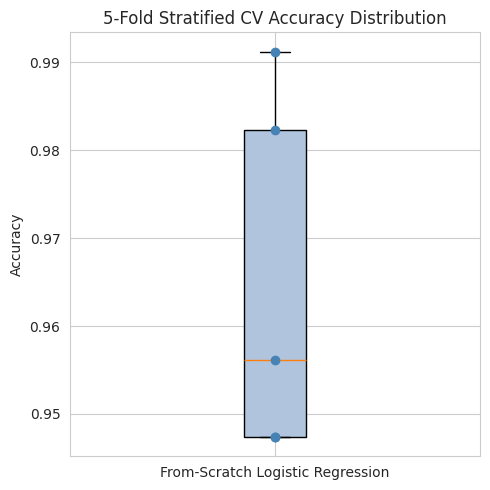

In [30]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.boxplot(cv_accuracies, vert=True, patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue"))
ax.scatter(np.ones_like(cv_accuracies), cv_accuracies, color="steelblue", zorder=3)
ax.set_xticklabels(["From-Scratch Logistic Regression"])
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold Stratified CV Accuracy Distribution")
plt.tight_layout()
plt.show()

In [31]:
## 12. Learning Curve (Bias / Variance Diagnostic)


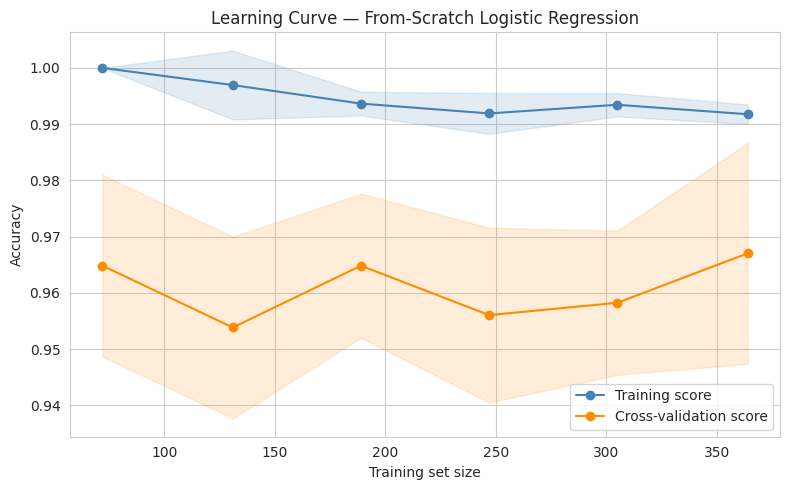

In [32]:
from sklearn.base import BaseEstimator, ClassifierMixin

class ScratchLogisticRegression(BaseEstimator, ClassifierMixin):
    """Thin sklearn-compatible wrapper around the from-scratch implementation,
    purely so we can reuse sklearn's learning_curve plumbing."""
    def __init__(self, lr=0.5, num_iter=500, lam=0.05):
        self.lr, self.num_iter, self.lam = lr, num_iter, lam

    def fit(self, X, y):
        self.theta_, _ = train_logistic_regression(X, y, optimizer="adam",
                                                     lr=self.lr, num_iter=self.num_iter, lam=self.lam)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        return predict(X, self.theta_, threshold=0.5)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


train_sizes, train_scores, val_scores = learning_curve(
    ScratchLogisticRegression(), X_train_s, y_train,
    train_sizes=np.linspace(0.2, 1.0, 6), cv=5, scoring="accuracy", random_state=42
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="steelblue", label="Training score")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="darkorange", label="Cross-validation score")
ax.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color="steelblue")
ax.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="darkorange")
ax.set_xlabel("Training set size")
ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve — From-Scratch Logistic Regression")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()